# GARCH(1,1) 변동성 모형

**대상**: SPY, QQQ | **기간**: 2016-01-01 ~ 2025-12-31

## 분석 흐름

1. Normal GARCH(1,1) 적합
2. **표준화 잔차 정규성 검정** — 혁신항 분포 가정이 맞는지 확인
3. fat-tail 잔존 확인 → t-분포 GARCH(1,1) 적합
4. Normal vs t-GARCH 비교

## GARCH(1,1) 구조

수익률 방정식: $r_t = \mu + \varepsilon_t$, 단 $\varepsilon_t = \sigma_t z_t$

분산 방정식: $\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$

- 분포 가정: $z_t \sim N(0,1)$ (Normal) 또는 $z_t \sim t_\nu$ (Student-t)
- **어느 분포가 맞는지는 raw 수익률이 아니라 표준화 잔차 $z_t$를 보고 판단**
  - GARCH 구조 자체가 시변 분산으로 unconditional fat-tail을 만들 수 있으므로,
    raw 수익률의 fat-tail ≠ 혁신항의 fat-tail

## §1. 환경 설정

In [ ]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display

# ── 한글 폰트 ──────────────────────────────────────────────
import platform
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 시드 고정 ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── 경로 상수 (노트북 CWD = 시계열_Test/Garch/) ────────────
GARCH_DIR    = Path('.').resolve()
RAW_DATA_DIR = (Path('../Phase1_LSTM/results/raw_data')).resolve()

assert RAW_DATA_DIR.exists(), f'데이터 경로 없음: {RAW_DATA_DIR}'

pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', 20)

print('[OK] Garch 환경 설정 완료')
print(f'  GARCH_DIR    = {GARCH_DIR}')
print(f'  RAW_DATA_DIR = {RAW_DATA_DIR}')
print(f'  SEED = {SEED}')

In [4]:
from arch import arch_model
from scipy import stats
from scipy.stats import jarque_bera as jb_test
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import warnings
warnings.filterwarnings('ignore')

TICKERS = ['SPY', 'QQQ']
ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'

print('[OK] arch 패키지 import 완료')

[OK] arch 패키지 import 완료


## §2. 데이터 로드

In [5]:
raw_dict = {}
for tic in TICKERS:
    csv_path = RAW_DATA_DIR / f'{tic}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    df['log_return'] = np.log(df['Adj Close']).diff()
    raw_dict[tic] = df

# 분석 기간, % 단위 변환 (arch 권고: 소수 단위면 최적화 불안정)
ret_dict = {
    tic: raw_dict[tic].loc[ANALYSIS_START:ANALYSIS_END, 'log_return'].dropna() * 100
    for tic in TICKERS
}

for tic, lr in ret_dict.items():
    print(f'[{tic}] 샘플 수: {len(lr)},  평균: {lr.mean():.4f}%,  표준편차: {lr.std():.4f}%')

[SPY] 샘플 수: 2514,  평균: 0.0546%,  표준편차: 1.1370%
[QQQ] 샘플 수: 2514,  평균: 0.0706%,  표준편차: 1.4101%


## §3. GARCH 적합 전제 조건 확인 (EDA 요약)

GARCH를 적합하기 전에 `01_eda_statistics.ipynb`에서 확인한 세 가지 전제 조건을 정리한다.

### 3-1. 전제 조건 체크리스트

| 전제 조건 | 검정 | 결과 | GARCH에서의 의미 |
|---|---|---|---|
| **수익률 정상성** | ADF + KPSS | 두 검정 모두 정상 ✓ | GARCH 적합 가능 — 추가 차분 불필요 |
| **ARCH 효과 존재** | Engle ARCH-LM | p ≈ 0 ✓ | GARCH를 쓸 동기 확보 |
| **수익률 자기상관** | ACF (lag 1~10) | SPY −0.13, QQQ −0.12 (크기 작음) | `mean='Constant'` 채택 근거 |
| **fat-tail** | Jarque-Bera | p ≈ 0, 초과 첨도 SPY 15.1 / QQQ 7.9 | Normal vs t-분포 비교 필요성 예고 |

### 3-2. ARCH-LM 결과 (GARCH 동기)

| | ARCH-LM 통계량 (lag 5) | p-value | 판정 |
|---|---|---|---|
| SPY | 721.2 | ≈ 0 | ARCH 효과 존재 ✓ |
| QQQ | 503.0 | ≈ 0 | ARCH 효과 존재 ✓ |

수익률 자체(ACF 최대 0.13)보다 변동성(제곱 수익률)에 훨씬 강한 시간 구조가 존재 → **GARCH 적합 전제 충족**.

### 3-3. mean='Constant' 선택 근거

EDA ACF 분석에서 수익률 자기상관이 통계적으로 유의하지만 크기가 작다.

| | lag 1 ACF | 95% CI | 통계적 유의 |
|---|---|---|---|
| SPY | −0.133 | ±0.039 | ✓ (유의하나 미미) |
| QQQ | −0.123 | ±0.039 | ✓ (유의하나 미미) |

lag 1 ACF = −0.13이면 전날 수익률로 오늘을 선형 설명하는 R² ≈ 1.7%에 불과하다.  
AR항을 추가한 ARMA-GARCH도 가능하지만, 파라미터 추가 대비 이득이 미미하고 **분산 방정식에 집중**하는 것이 이 분석의 목적에 부합한다.

→ **`mean='Constant'`** 채택. (AR 효과가 유의미하게 크다면 `mean='AR'`로 확장 가능)

### 3-4. 분포 선택 방향

raw 수익률 JB p≈0 (초과 첨도 SPY 15.1, QQQ 7.9)은 분포 선택의 직접 근거가 아니다.  
GARCH 구조 자체가 시변 분산으로 unconditional fat-tail을 만들 수 있으므로, **혁신항 분포는 표준화 잔차 $z_t = \varepsilon_t / \hat{\sigma}_t$ 를 기준으로 판단해야 한다** (§4에서 확인).

## §3. Normal GARCH(1,1) 적합

먼저 정규분포 가정으로 적합한다.  
이후 §4에서 표준화 잔차의 정규성을 검정해 이 가정이 타당한지 확인한다.

In [6]:
fit_normal = {}

for tic in TICKERS:
    model = arch_model(
        ret_dict[tic],
        mean='Constant', vol='GARCH', p=1, q=1, dist='Normal',
    )
    res = model.fit(disp='off')
    fit_normal[tic] = res
    p = res.params
    print(f'[{tic}] Normal GARCH(1,1)')
    print(f'  μ={p["mu"]:.4f}  ω={p["omega"]:.5f}  α={p["alpha[1]"]:.4f}  β={p["beta[1]"]:.4f}  α+β={p["alpha[1]"]+p["beta[1]"]:.4f}')
    print(f'  AIC={res.aic:.2f}  BIC={res.bic:.2f}  LogLik={res.loglikelihood:.2f}')
    print()

[SPY] Normal GARCH(1,1)
  μ=0.0906  ω=0.03790  α=0.1805  β=0.7910  α+β=0.9715
  AIC=6472.36  BIC=6495.68  LogLik=-3232.18

[QQQ] Normal GARCH(1,1)
  μ=0.1073  ω=0.04875  α=0.1405  β=0.8364  α+β=0.9769
  AIC=7947.26  BIC=7970.58  LogLik=-3969.63



## §4. 표준화 잔차 정규성 검정

Normal GARCH(1,1)의 분포 가정이 타당한지는 **raw 수익률이 아니라 표준화 잔차 $z_t = \varepsilon_t / \hat{\sigma}_t$로 판단**해야 한다.

- GARCH 구조는 시변 분산 $\sigma_t^2$으로 변동성 클러스터링을 흡수하므로, 혁신항이 $N(0,1)$이어도 unconditional fat-tail이 생길 수 있다.
- $\sigma_t$를 걷어낸 뒤 $z_t$에 fat-tail이 남아 있다면 → 혁신항 분포 자체가 비정규 → t-분포 GARCH 필요

### 검정 항목
| 검정 | 귀무가설 | p < 0.05 의미 |
|---|---|---|
| Jarque-Bera | 왜도=0, 첨도=3 (정규분포) | 비정규 — 분포 재검토 필요 |
| Ljung-Box | 자기상관 없음 | 잔여 선형 구조 |
| ARCH-LM | ARCH 효과 없음 | 잔여 변동성 클러스터링 |

In [7]:
resid_normal = {}

print('=== Normal GARCH(1,1) 표준화 잔차 진단 ===')
print()

diag_rows = []
for tic in TICKERS:
    res = fit_normal[tic]
    z = res.resid / res.conditional_volatility
    resid_normal[tic] = z

    jb_stat, jb_p   = jb_test(z)
    lb_p  = acorr_ljungbox(z,    lags=[10], return_df=True)['lb_pvalue'].values[0]
    lm_p  = het_arch(z, nlags=10)[1]
    skew  = float(pd.Series(z).skew())
    kurt  = float(pd.Series(z).kurt())   # excess kurtosis

    diag_rows.append({
        'ticker': tic,
        'JB 통계량': round(jb_stat, 2),
        'JB p-value': f'{jb_p:.2e}',
        '정규성': '✓' if jb_p > 0.05 else '✗ fat-tail 잔존',
        'LB p (lag10)': round(lb_p, 4),
        'ARCH-LM p (lag10)': round(lm_p, 4),
        '왜도': round(skew, 4),
        '초과 첨도': round(kurt, 4),
    })

    print(f'[{tic}]')
    print(f'  Jarque-Bera  : stat={jb_stat:.1f},  p={jb_p:.2e}  →  {"정규 ✓" if jb_p > 0.05 else "비정규 ✗ (fat-tail 잔존)"}')
    print(f'  Ljung-Box    : p={lb_p:.4f}  →  {"자기상관 없음 ✓" if lb_p > 0.05 else "잔여 자기상관 ⚠️"}')
    print(f'  ARCH-LM      : p={lm_p:.4f}  →  {"ARCH 효과 제거 ✓" if lm_p > 0.05 else "잔여 ARCH 효과 ⚠️"}')
    print(f'  왜도={skew:.4f}, 초과 첨도={kurt:.4f}')
    print()

display(pd.DataFrame(diag_rows).set_index('ticker'))

=== Normal GARCH(1,1) 표준화 잔차 진단 ===

[SPY]
  Jarque-Bera  : stat=1015.6,  p=2.89e-221  →  비정규 ✗ (fat-tail 잔존)
  Ljung-Box    : p=0.6633  →  자기상관 없음 ✓
  ARCH-LM      : p=0.2674  →  ARCH 효과 제거 ✓
  왜도=-0.7670, 초과 첨도=2.7180

[QQQ]
  Jarque-Bera  : stat=516.2,  p=7.92e-113  →  비정규 ✗ (fat-tail 잔존)
  Ljung-Box    : p=0.5314  →  자기상관 없음 ✓
  ARCH-LM      : p=0.2143  →  ARCH 효과 제거 ✓
  왜도=-0.6175, 초과 첨도=1.8513



,JB 통계량,JB p-value,정규성,LB p (lag10),ARCH-LM p (lag10),왜도,초과 첨도
ticker,,,,,,,
SPY,1015.620000,2.89e-221,✗ fat-tail 잔존,0.663300,0.267400,-0.767000,2.718000
QQQ,516.250000,7.92e-113,✗ fat-tail 잔존,0.531400,0.214300,-0.617500,1.851300


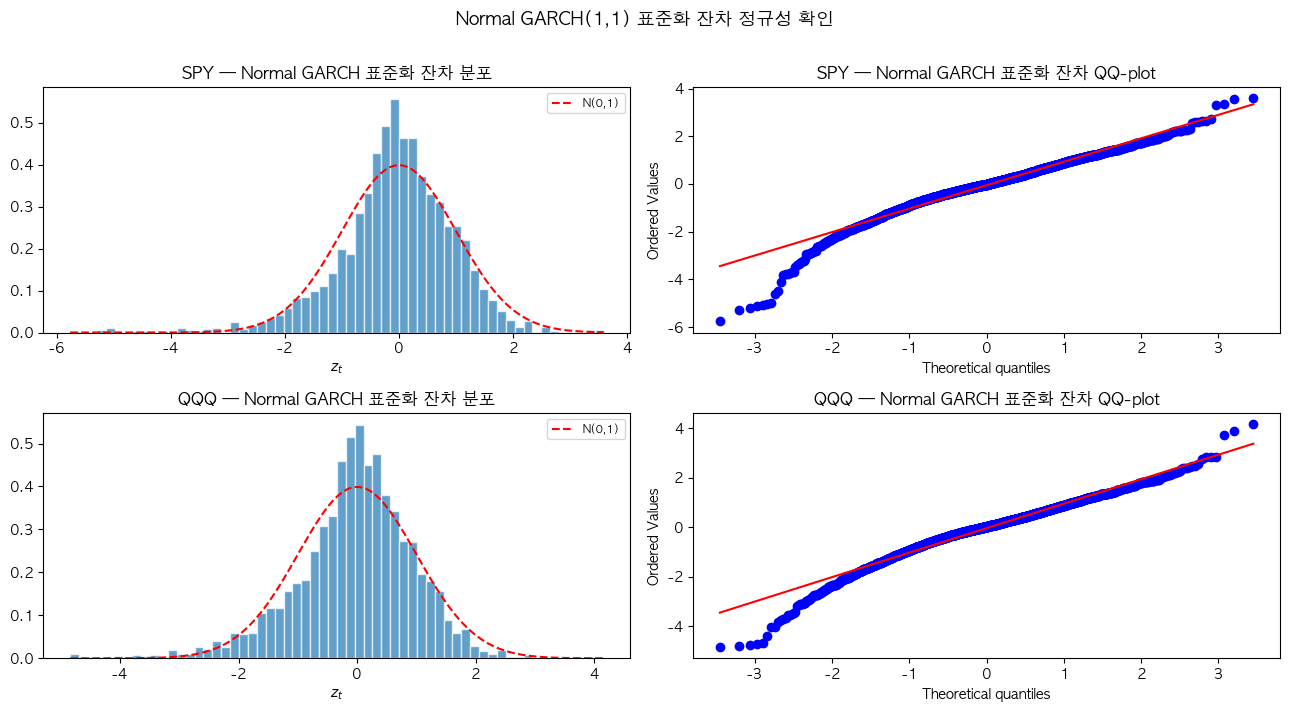

[판정] QQ-plot 꼬리 이탈 + JB p≈0 → 혁신항에 fat-tail 잔존 → t-분포 GARCH로 교체 필요


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for row, tic in enumerate(TICKERS):
    z = resid_normal[tic]

    # 히스토그램 + N(0,1) 오버레이
    ax_h = axes[row, 0]
    ax_h.hist(z, bins=60, edgecolor='white', alpha=0.7, density=True)
    x = np.linspace(z.min(), z.max(), 300)
    ax_h.plot(x, stats.norm.pdf(x), 'r--', linewidth=1.5, label='N(0,1)')
    ax_h.set_title(f'{tic} — Normal GARCH 표준화 잔차 분포')
    ax_h.set_xlabel('$z_t$')
    ax_h.legend(fontsize=8)

    # QQ-plot
    ax_q = axes[row, 1]
    stats.probplot(z, dist='norm', plot=ax_q)
    ax_q.set_title(f'{tic} — Normal GARCH 표준화 잔차 QQ-plot')

plt.suptitle('Normal GARCH(1,1) 표준화 잔차 정규성 확인', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('[판정] QQ-plot 꼬리 이탈 + JB p≈0 → 혁신항에 fat-tail 잔존 → t-분포 GARCH로 교체 필요')

## §5. t-분포 GARCH(1,1) 적합

§4 결과: 표준화 잔차 JB p≈0, 초과 첨도 > 0 → 혁신항에 fat-tail 잔존 → `dist='StudentsT'`로 교체

t-분포 GARCH는 자유도 $\nu$를 추가 파라미터로 추정한다.
- $\nu$ 작을수록 꼬리가 두꺼움 (보통 금융 데이터: 4~8)
- $\nu \to \infty$ : 정규분포로 수렴

> **QQQ α+β 경계값 주의**: 아래 결과에서 QQQ의 α+β가 1.0000으로 수렴한다.
> 이는 **IGARCH(Integrated GARCH)** 경계로, 장기 분산 $\sigma^2 = \omega/(1-\alpha-\beta)$ 공식이 발산(분모=0)하여 정의되지 않는다.
> 변동성 충격이 이론적으로 영원히 소멸하지 않는다는 의미이며, 나스닥 100(QQQ)처럼 변동성이 높고 구조적 충격이 잦은 지수에서 흔히 나타난다.

In [9]:
fit_t = {}

for tic in TICKERS:
    model = arch_model(
        ret_dict[tic],
        mean='Constant', vol='GARCH', p=1, q=1, dist='StudentsT',
    )
    res = model.fit(disp='off')
    fit_t[tic] = res
    p = res.params
    print(f'[{tic}] t-GARCH(1,1)')
    print(f'  μ={p["mu"]:.4f}  ω={p["omega"]:.5f}  α={p["alpha[1]"]:.4f}  β={p["beta[1]"]:.4f}  α+β={p["alpha[1]"]+p["beta[1]"]:.4f}')
    print(f'  자유도 ν={p["nu"]:.4f}')
    print(f'  AIC={res.aic:.2f}  BIC={res.bic:.2f}  LogLik={res.loglikelihood:.2f}')
    print()

[SPY] t-GARCH(1,1)
  μ=0.1049  ω=0.02055  α=0.1720  β=0.8249  α+β=0.9968
  자유도 ν=5.2385
  AIC=6271.28  BIC=6300.43  LogLik=-3130.64

[QQQ] t-GARCH(1,1)
  μ=0.1453  ω=0.02567  α=0.1437  β=0.8563  α+β=1.0000
  자유도 ν=5.2904
  AIC=7792.37  BIC=7821.52  LogLik=-3891.18



## §6. Normal vs t-GARCH 비교

### 6-1. 파라미터 및 적합도

In [10]:
rows = []
for tic in TICKERS:
    for label, fit in [('Normal', fit_normal[tic]), ('t', fit_t[tic])]:
        p = fit.params
        row = {
            'ticker': tic, '분포': label,
            'α': round(p['alpha[1]'], 4),
            'β': round(p['beta[1]'], 4),
            'α+β': round(p['alpha[1]'] + p['beta[1]'], 4),
            '장기σ(%/yr)': round(np.sqrt(p['omega'] / (1 - p['alpha[1]'] - p['beta[1]'])) * np.sqrt(252), 2),
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'LogLik': round(fit.loglikelihood, 2),
        }
        if label == 't':
            row['ν (자유도)'] = round(p['nu'], 2)
        else:
            row['ν (자유도)'] = '—'
        rows.append(row)

cmp_df = pd.DataFrame(rows).set_index(['ticker', '분포'])
display(cmp_df)

print()
print('[AIC/BIC 해석] 낮을수록 우수한 적합도 (패널티 포함)')
for tic in TICKERS:
    aic_n = fit_normal[tic].aic
    aic_t = fit_t[tic].aic
    bic_n = fit_normal[tic].bic
    bic_t = fit_t[tic].bic
    print(f'  {tic}: ΔAIC={aic_n - aic_t:.2f}  ΔBIC={bic_n - bic_t:.2f}  → {"t-GARCH 우수" if aic_t < aic_n else "Normal GARCH 우수"}')

α        β      α+β  장기σ(%/yr)         AIC         BIC       LogLik  ν (자유도)
ticker 분포                                                                                        
SPY    Normal 0.180500 0.791000 0.971500  18.300000 6472.360000 6495.680000 -3232.180000        —
       t      0.172000 0.824900 0.996800  40.370000 6271.280000 6300.430000 -3130.640000 5.240000
QQQ    Normal 0.140500 0.836400 0.976900  23.060000 7947.260000 7970.580000 -3969.630000        —
       t      0.143700 0.856300 1.000000        inf 7792.370000 7821.520000 -3891.180000 5.290000


[AIC/BIC 해석] 낮을수록 우수한 적합도 (패널티 포함)
  SPY: ΔAIC=201.08  ΔBIC=195.25  → t-GARCH 우수
  QQQ: ΔAIC=154.89  ΔBIC=149.06  → t-GARCH 우수


### 6-2. t-GARCH 표준화 잔차 진단

t-분포로 교체 후 잔여 구조(자기상관, ARCH 효과)가 제거됐는지 확인한다.

**정규성(JB) 해석 주의**: t-GARCH의 혁신항은 $z_t \sim t_\nu$ 를 가정하므로, 표준화 잔차를 정규분포와 비교하는 JB 검정에서 p≈0이 나오는 것은 **당연하다** — 모형이 잘못된 게 아니라 분포 가정 자체가 다르기 때문.
개선 여부는 JB가 아니라 **AIC/BIC 감소** 및 **초과 첨도 변화**로 판단한다.

In [11]:
print('=== t-GARCH(1,1) 표준화 잔차 진단 ===')
print()

resid_t = {}
for tic in TICKERS:
    res = fit_t[tic]
    z = res.resid / res.conditional_volatility
    resid_t[tic] = z

    jb_stat, jb_p = jb_test(z)
    lb_p  = acorr_ljungbox(z, lags=[10], return_df=True)['lb_pvalue'].values[0]
    lm_p  = het_arch(z, nlags=10)[1]
    kurt  = float(pd.Series(z).kurt())
    skew  = float(pd.Series(z).skew())

    print(f'[{tic}]')
    print(f'  Jarque-Bera  : p={jb_p:.2e}  →  {"정규 ✓" if jb_p > 0.05 else "비정규 ✗"}')
    print(f'  Ljung-Box    : p={lb_p:.4f}  →  {"자기상관 없음 ✓" if lb_p > 0.05 else "잔여 자기상관 ⚠️"}')
    print(f'  ARCH-LM      : p={lm_p:.4f}  →  {"ARCH 효과 제거 ✓" if lm_p > 0.05 else "잔여 ARCH 효과 ⚠️"}')
    print(f'  왜도={skew:.4f}, 초과 첨도={kurt:.4f}')
    print()

=== t-GARCH(1,1) 표준화 잔차 진단 ===

[SPY]
  Jarque-Bera  : p=1.66e-296  →  비정규 ✗
  Ljung-Box    : p=0.7086  →  자기상관 없음 ✓
  ARCH-LM      : p=0.2896  →  ARCH 효과 제거 ✓
  왜도=-0.8558, 초과 첨도=3.1832

[QQQ]
  Jarque-Bera  : p=6.22e-156  →  비정규 ✗
  Ljung-Box    : p=0.5520  →  자기상관 없음 ✓
  ARCH-LM      : p=0.2554  →  ARCH 효과 제거 ✓
  왜도=-0.6810, 초과 첨도=2.2363



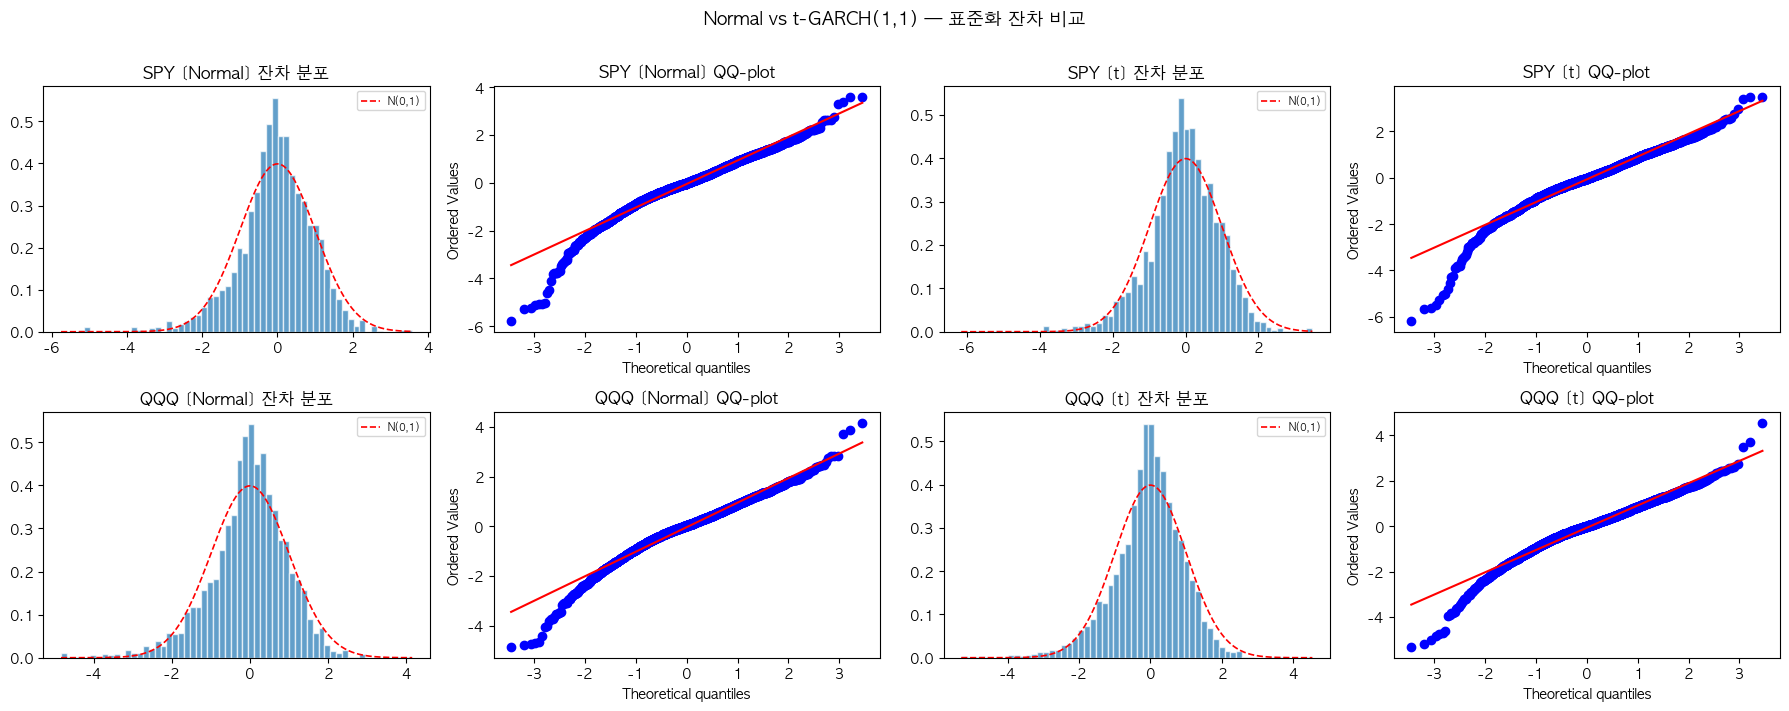

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for row, tic in enumerate(TICKERS):
    for col, (label, z) in enumerate([
        ('Normal', resid_normal[tic]),
        ('t', resid_t[tic]),
    ]):
        # 히스토그램
        ax_h = axes[row, col * 2]
        ax_h.hist(z, bins=60, edgecolor='white', alpha=0.7, density=True)
        x = np.linspace(z.min(), z.max(), 300)
        ax_h.plot(x, stats.norm.pdf(x), 'r--', linewidth=1.2, label='N(0,1)')
        ax_h.set_title(f'{tic} [{label}] 잔차 분포')
        ax_h.legend(fontsize=7)

        # QQ-plot
        ax_q = axes[row, col * 2 + 1]
        stats.probplot(z, dist='norm', plot=ax_q)
        ax_q.set_title(f'{tic} [{label}] QQ-plot')

plt.suptitle('Normal vs t-GARCH(1,1) — 표준화 잔차 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6-3. 조건부 변동성 비교 (Normal vs t)

[SPY] |t - Normal| 평균 차이: 0.6498%  최대 차이: 7.7495%
[QQQ] |t - Normal| 평균 차이: 0.8983%  최대 차이: 7.0507%


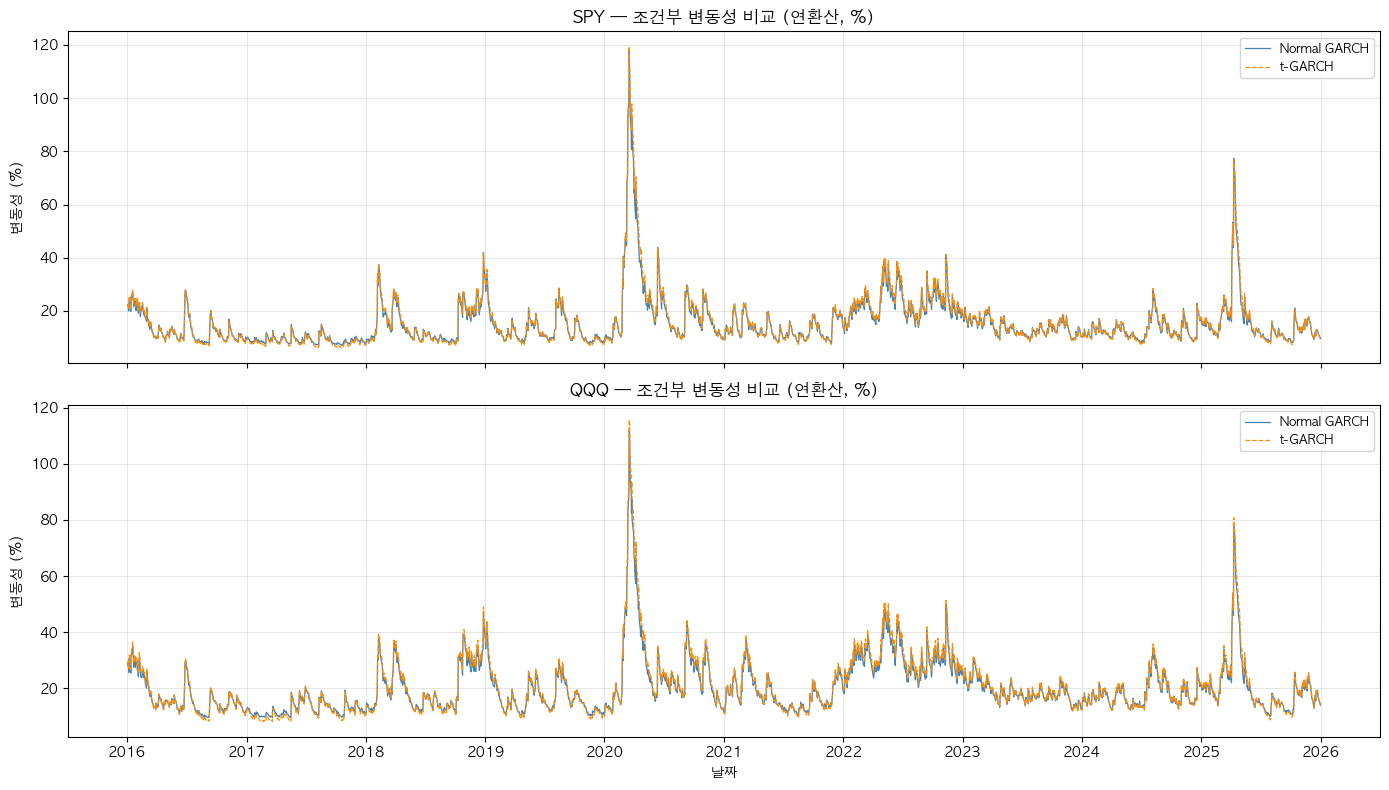

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for row, tic in enumerate(TICKERS):
    cv_n = fit_normal[tic].conditional_volatility * np.sqrt(252)
    cv_t = fit_t[tic].conditional_volatility * np.sqrt(252)

    ax = axes[row]
    ax.plot(cv_n.index, cv_n.values, color='steelblue', linewidth=0.9, label='Normal GARCH')
    ax.plot(cv_t.index, cv_t.values, color='darkorange', linewidth=0.9, linestyle='--', label='t-GARCH')
    ax.set_title(f'{tic} — 조건부 변동성 비교 (연환산, %)')
    ax.set_ylabel('변동성 (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    diff = (cv_t - cv_n).abs()
    print(f'[{tic}] |t - Normal| 평균 차이: {diff.mean():.4f}%  최대 차이: {diff.max():.4f}%')

axes[-1].set_xlabel('날짜')
plt.tight_layout()
plt.show()

## §7. 결론

### 분포 선택 판단 근거

| 확인 항목 | SPY | QQQ | 판정 |
|---|---|---|---|
| Normal GARCH 잔차 JB p | ≈ 0 | ≈ 0 | 혁신항 비정규 → t-분포 필요 |
| Normal GARCH 잔차 초과 첨도 | 2.72 | 1.85 | fat-tail 잔존 |
| ΔAIC (Normal − t) | **201.08** | **154.89** | t-GARCH 우수 |
| ΔBIC (Normal − t) | **195.25** | **149.06** | 파라미터 1개 추가해도 우수 |
| t-GARCH 자유도 ν | **5.24** | **5.29** | fat-tail 두꺼움 (4~8 범위 — 전형적) |

### 파라미터 요약 (t-GARCH 기준)

| | SPY | QQQ |
|---|---|---|
| α (즉각 반응) | 0.1720 | 0.1437 |
| β (지속성) | 0.8249 | 0.8563 |
| **α+β** | **0.9968** | **1.0000 ⚠️** |
| 자유도 ν | 5.24 | 5.29 |
| 장기 연환산 σ | 18.3% (Normal 기준) | **IGARCH — 정의 불가** |

> **QQQ α+β=1.0000**: IGARCH 경계 도달 — 변동성 충격이 이론적으로 영구 지속.
> 장기 σ 공식($\omega/(1-\alpha-\beta)$)이 발산하므로 Normal 기준 23.1%는 참고값으로만 사용.

### 개선 여부 (Normal → t-GARCH)

| | Normal 잔차 초과 첨도 | t-GARCH 잔차 초과 첨도 | 비고 |
|---|---|---|---|
| SPY | 2.72 | 3.18 | AIC −201 — 분포 적합도 크게 향상 |
| QQQ | 1.85 | 2.24 | AIC −155 — 분포 적합도 크게 향상 |

> 초과 첨도가 소폭 증가한 것은 t-GARCH의 $\sigma_t$ 추정값이 달라진 데 따른 스케일 효과이며,
> 모형 품질 지표인 AIC/BIC가 크게 감소했으므로 t-GARCH가 명확히 우수하다.

### 한계 및 다음 단계
- **레버리지 효과**: 잔차 왜도 SPY −0.86, QQQ −0.68 → 하락 충격이 변동성을 더 키우는 비대칭 구조 존재
  → GJR-GARCH 또는 EGARCH로 확장 가능
- **QQQ IGARCH**: α+β=1 경계는 추정 불안정 신호일 수 있음 — 표본 기간 변경 또는 IGARCH 명시 적합 검토